<a href="https://colab.research.google.com/github/lazarosgogos/ML-exercises/blob/main/ML_Project_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# -- REINFORCEMENT LEARNING --

## Q1 - Install dependencies

In [ ]:
!pip install --quiet swig

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 34.1 MB/s eta 0:00:00


In [ ]:
!pip install --quiet gymnasium[box2d]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 49.6 MB/s eta 0:00:00


In [ ]:
!pip install --quiet renderlab

In [ ]:
!pip install --quiet rllib

In [ ]:
!pip install --quiet stable-baselines3[extra]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 4.5 MB/s eta 0:00:00


## Q2 - `step`, `reset` and `render` explanation
* `step`: for a given environment state, this function takes into account the agent's action and produces the next state, after also producing the reward accordingly
* `reset`: this function resets the environment state to an initial internal state, generating a new random starting state
* `render`: this function returns an array which can be rendered to the screen as pixels, or it can be fed to a Neural Network to train an RL agent

## Q3 - Describing the `LunarLander` environment
1) Observation space: The state is an 8-dimensional vector: the coordinates of the lander in x & y, its linear velocities in x & y, its angle, its angular velocity, and two booleans that represent whether each leg is in contact with the ground or not.
2) Action space: There are four discrete actions available:
    0) do nothing
    1) fire left orientation engine
    2) fire main engine
    3) fire right orientation engine
3) Reward function: After every step a reward is granted. The total reward of an episode is the sum of the rewards for all the steps within that episode.
For each step, the reward:
    * is increased/decreased the closer/further the lander is to the landing pad.
    * is increased/decreased the slower/faster the lander is moving.
    * is decreased the more the lander is tilted (angle not horizontal).
    * is increased by 10 points for each leg that is in contact with the ground.
    * is decreased by 0.03 points each frame a side engine is firing.
    * is decreased by 0.3 points each frame the main engine is firing.

    The episode receive an additional reward of -100 or +100 points for crashing or landing safely respectively.\
    An episode is considered a solution if it scores at least 200 points.

## Q4 - Create an RL agent and visualize its progress

### Import libraries

In [ ]:
import renderlab as rl
import gymnasium as gym
from stable_baselines3 import DQN, PPO
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.vec_env import SubprocVecEnv, VecNormalize
import matplotlib.pyplot as plt
import numpy as np
import os

/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:294: SyntaxWarning: invalid escape sequence '\d'
  lines_video = [l for l in lines if ' Video: ' in l and re.search('\d+x\d+', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:367: SyntaxWarning: invalid escape sequence '\d'
  rotation_lines = [l for l in lines if 'rotate          :' in l and re.search('\d+$', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:370: SyntaxWarning: invalid escape sequence '\d'
  match = re.search('\d+$', rotation_line)
  if event.key is 'enter':

  return datetime.utcnow().replace(tzinfo=utc)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintaine

In [ ]:

env = gym.make("LunarLander-v3", render_mode="rgb_array")
env = rl.RenderFrame(env, "./output")

observation, info = env.reset()

while True:
  action = env.action_space.sample()
  observation, reward, terminated, truncated, info = env.step(action)

  if terminated or truncated:
    break

env.play()

## Q5 - Average score after 5 random episodes

In [ ]:
env = gym.make("LunarLander-v3") #, render_mode="rgb_array")
observation, info = env.reset()

count = 0
total_reward = 0
while count < 5:
  action = env.action_space.sample()
  observation, reward, terminated, truncated, info = env.step(action)
  total_reward += reward
  done = terminated or truncated
  if done:
    count += 1

total_reward /= count # get average
print(f"Average reward of a random agent: {total_reward}")

Average reward of a random agent: -172.7335629907389


## Q6 - Train an agent using StableBaselines

### a) Deep Q Network (DQN)

In [ ]:
env = gym.make("LunarLander-v3", render_mode="rgb_array")

if not os.path.isfile("/content/dqn_lunar.zip"):
  model = DQN("MlpPolicy", env)
  model.learn(total_timesteps=int(2e5), progress_bar=True)

  model.save("dqn_lunar")
else:
  model = DQN.load("dqn_lunar", env=env)
mean_reward, std_reward = evaluate_policy(model, model.get_env(),
                                          n_eval_episodes=100)

print(f"Mean score: {mean_reward}, std: {std_reward}")

Mean score: -70.38566807000001, std: 65.19610928268155

#### visualise DQN episode

In [ ]:
# Create env with rgb_array rendering
env = gym.make("LunarLander-v3", render_mode="rgb_array")

# model = DQN.load("dqn_lunar", env=env)

frames = []

obs, info = env.reset()
while True:
  action, _ = model.predict(obs, deterministic=True)
  obs, reward, terminated, truncated, info = env.step(action)

  frame = env.render()
  frames.append(frame)

  if terminated or truncated:
    obs, info = env.reset()
    break

env.close()


In [ ]:
from matplotlib import animation
from IPython.display import HTML
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(5,5))
plt.axis("off")
img = plt.imshow(frames[0])

def animate(i):
  img.set_data(frames[i])
  return [img]

anim = animation.FuncAnimation(
  fig, animate, frames=len(frames), interval=30
)
anim.save("ppo_lunar.gif")
HTML(anim.to_jshtml())

### b) Proximal Policy Optimization (PPO)

In [ ]:
env = gym.make("LunarLander-v3", render_mode="rgb_array")

if not os.path.isfile("/content/ppo_lunar.zip"):
  model = PPO("MlpPolicy", env)#, verbose=0)
  model.learn(total_timesteps=int(2e5), progress_bar=True)

  model.save("ppo_lunar")
else:
  model = PPO.load("ppo_lunar", env=env)

mean_reward_ppo, std_reward_ppo = evaluate_policy(model, model.get_env(),
                                          n_eval_episodes=10)

print(f"Mean score: {mean_reward_ppo}, std: {std_reward_ppo}")

Mean score: -99.3233315, std: 55.1958277787069

## Q7 - Average score after training + metrics

Text(0.5, 1.0, 'DQN - Average Reward per Environment Step (Mean ± Std)')

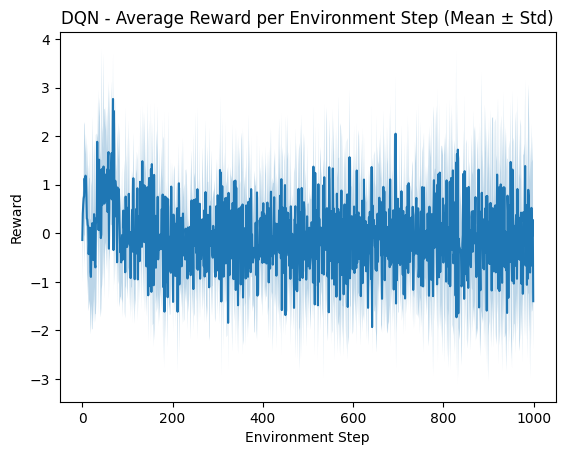

In [ ]:
env = gym.make("LunarLander-v3")
obs, _ = env.reset()
model = DQN.load("dqn_lunar")
num_episodes = 5
rewards = []

for _ in range(num_episodes):
  done = False
  episode_rewards = []

  while not done:
    action, _ = model.predict(obs)
    obs, reward, terminated, truncated, _ = env.step(action)
    episode_rewards.append(reward)
    done = terminated or truncated

  rewards.append(episode_rewards)
  obs, _ = env.reset()

env.close()

# pad episodes to same length
max_len = max(len(r) for r in rewards)
padded = np.full((num_episodes, max_len), np.nan)

for i, r in enumerate(rewards):
    padded[i, :len(r)] = r

mean_rewards = np.nanmean(padded, axis=0)
std_rewards = np.nanstd(padded, axis=0)

plt.plot(mean_rewards)
plt.fill_between(
    range(len(mean_rewards)),
    mean_rewards - std_rewards,
    mean_rewards + std_rewards, alpha=.3
)
plt.xlabel("Environment Step")
plt.ylabel("Reward")
plt.title("DQN - Average Reward per Environment Step (Mean ± Std)")

Text(0.5, 1.0, 'PPO - Average Reward per Environment Step (Mean ± Std)')

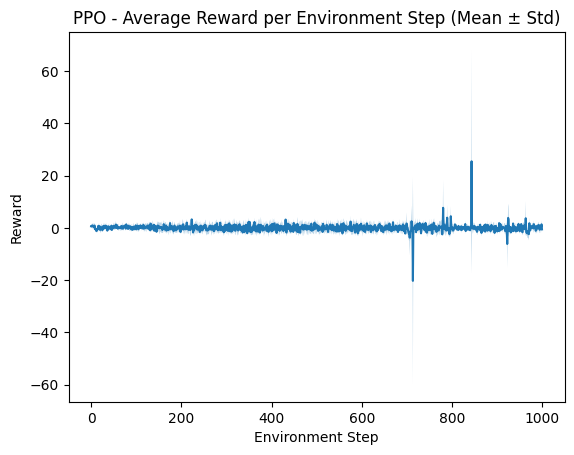

In [ ]:
env = gym.make("LunarLander-v3")
obs, _ = env.reset()
model = PPO.load("ppo_lunar.zip")
num_episodes = 5
rewards = []

for _ in range(num_episodes):
  done = False
  episode_rewards = []

  while not done:
    action, _ = model.predict(obs)
    obs, reward, terminated, truncated, _ = env.step(action)
    episode_rewards.append(reward)
    done = terminated or truncated

  rewards.append(episode_rewards)
  obs, _ = env.reset()

env.close()

# pad episodes to same length
max_len = max(len(r) for r in rewards)
padded = np.full((num_episodes, max_len), np.nan)

for i, r in enumerate(rewards):
  padded[i, :len(r)] = r

mean_rewards = np.nanmean(padded, axis=0)
std_rewards = np.nanstd(padded, axis=0)

plt.plot(mean_rewards)
plt.fill_between(
  range(len(mean_rewards)),
  mean_rewards - std_rewards,
  mean_rewards + std_rewards, alpha=.3
)
plt.xlabel("Environment Step")
plt.ylabel("Reward")
plt.title("PPO - Average Reward per Environment Step (Mean ± Std)")

### Training time
Training time is comparable between the DQN and PPO approaches, ~10 minutes using a CPU for 200 thousand epochs.

## Q8 - Optimize the Lunar Landing agent

Firstly, we must parallelize the training process, and we can do so by using StableBaseline's Vectorized Environments. Next, with some minor hyperparameter tuning, we can achieve good scores.

In [ ]:
env_id = "LunarLander-v3"
model_name = "ppo_lunar_opt"

def make_env():
  return gym.make(env_id)

# parallel environments
venv = SubprocVecEnv([make_env for _ in range(8)])
venv = VecNormalize(venv, norm_obs=True, norm_reward=True)

if not os.path.isfile(model_name + ".zip"):
  model = PPO(
    "MlpPolicy",
    venv,
    n_steps=1024,
    batch_size=256,
    gamma=0.999,
    gae_lambda=0.95,
    learning_rate=3e-4,
    ent_coef=0.01,
    clip_range=0.2,
    verbose=0,
  )
  model.learn(total_timesteps=1_000_000, progress_bar=True)
  model.save(model_name)
  venv.save("vecnormalize.pkl")
else:
  venv = VecNormalize.load("vecnormalize.pkl", venv)
  model = PPO.load(model_name, env=venv)

# evaluation (no normalization updates)
venv.training = False
venv.norm_reward = False

mean_reward_ppo_opt, std_reward_ppo_opt = evaluate_policy(
  model, venv, n_eval_episodes=10
)

print(f"Mean score: {mean_reward_ppo_opt}, std: {std_reward_ppo_opt}")


Mean score: 294.1235728427697, std: 15.529613718223755


Training time of the optimal model is 10 minutes (using a GPU)

  warnings.warn(



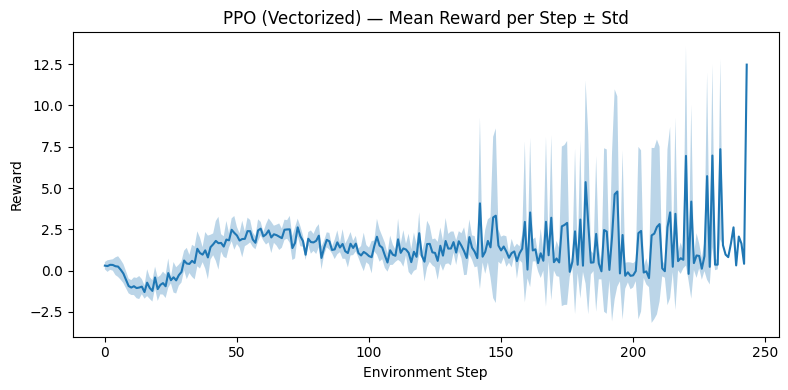

In [ ]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import SubprocVecEnv, VecNormalize

def make_env():
  return gym.make("LunarLander-v3")

# load vectorized env + normalization
venv = SubprocVecEnv([make_env for _ in range(8)])
venv = VecNormalize.load("vecnormalize.pkl", venv)
venv.training = False
venv.norm_reward = False

# load trained model
model = PPO.load("ppo_lunar_opt", env=venv)

# collect rewards
num_episodes = 5
rewards = []

for _ in range(num_episodes):
  obs = venv.reset()
  done = np.zeros(venv.num_envs, dtype=bool)
  episode_rewards = []

  while not done.all():
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, dones, _ = venv.step(action)

    episode_rewards.append(reward.mean())  # mean across envs
    done |= dones

  rewards.append(episode_rewards)

venv.close()

# pad episodes
max_len = max(len(r) for r in rewards)
padded = np.full((num_episodes, max_len), np.nan)

for i, r in enumerate(rewards):
  padded[i, :len(r)] = r

# per-step statistics
mean_rewards = np.nanmean(padded, axis=0)
std_rewards = np.nanstd(padded, axis=0)

# plot
plt.figure(figsize=(8, 4))
plt.plot(mean_rewards)
plt.fill_between(
  range(len(mean_rewards)),
  mean_rewards - std_rewards,
  mean_rewards + std_rewards,
  alpha=0.3
)
plt.xlabel("Environment Step")
plt.ylabel("Reward")
plt.title("PPO (Vectorized) — Mean Reward per Step ± Std")
plt.tight_layout()
plt.show()
